In [ ]:
# This is a python script for analysis of the models
import os,sys,subprocess, logging
import numpy as np
import matplotlib.pyplot as plt
import pickle

from matplotlib.collections import LineCollection
import matplotlib.cm as cm
from collections import Counter

from s01_agents import *
from s02_environment import *

pygame 2.5.2 (SDL 2.28.2, Python 3.10.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Generate Priors

In [2]:

save_dir = 'experiments/priors/OneDiffusion/'
if not os.path.exists(save_dir):
    os.mkdir(save_dir)
env_set = {
    # 'grid_size': 5,
    'grid_size': 9,
    'save_dir': save_dir,
}

ep = 0.6
reward_position1 = (0,int(env_set['grid_size']/2))
reward_position2 = (env_set['grid_size']-1,int(env_set['grid_size']/2))


agent = JointAgent(env_set['grid_size'], env_set['grid_size'], draw_radius=20, alpha=0.1, gamma=0.9, epsilon=ep)

neighbors1 = [(reward_position1[0]+idx_x, reward_position1[1]+idx_y) for (idx_x,idx_y) in [(-1,0),(1,0),(0,-1),(0,1)]]
neighbors2 = [(reward_position2[0]+idx_x, reward_position2[1]+idx_y) for (idx_x,idx_y) in [(-1,0),(1,0),(0,-1),(0,1)]]
neighbors = neighbors1 + neighbors2
for ele in neighbors:
    if ele == reward_position1 or ele == reward_position2:
        neighbors.remove(ele)
    if any(x<0 or x>env_set['grid_size']-1 for x in ele):
        neighbors.remove(ele)

all_states = [(i,j) for i in range(env_set['grid_size']) for j in range(env_set['grid_size'])]
prior_reward = 9
for ele in neighbors:
    for x in all_states:
        agent.q_values1[(ele,x)] = prior_reward
        agent.q_values2[(x,ele)] = prior_reward

agent.occupancy[(reward_position1,reward_position2)] = 0
plot_qval(agent, env_set)
qvals = {}
qvals['q_val1'] = agent.q_values1
qvals['q_val2'] = agent.q_values2
with open(env_set['save_dir']+'q_val_grid{}.pkl'.format(env_set['grid_size']), 'wb') as f:
    pickle.dump(qvals, f)


# Analysis of evaluation trajectory

In [10]:
# grid_size = 5
# model_dir = 'experiments/Independent/SameTargetReward/'
# model_dir = 'experiments/Independent/together_test0/'
# model_dir = 'experiments/Independent/together_test2/'
# model_dir = 'experiments/Independent/together_test3/'
# model_dir = 'experiments/Independent/together_test4/' 
# model_dir = 'experiments/Independent/together_test5/'
# model_dir = 'experiments/Independent/together_test10/'
# model_dir = 'experiments/SinglePredictor/PredictWhileReward/'
# model_dir = 'experiments/SinglePredictor/PredictFixInterval/'
# model_dir = 'experiments/AbsolutePredictor/'
grid_size = 9
model_dir = 'experiments/SinglePredictor/PredictFixInterval_Bigger/'
# model_dir = 'experiments/AbsolutePredictor_Bigger/'
save_dir = model_dir+ 'eval/'
with open(save_dir+'eval.pkl', 'rb') as f:
    data = pickle.load(f)

# with open(model_dir+'predictor_stats.pkl', 'rb') as f:
#     stats = pickle.load(f)

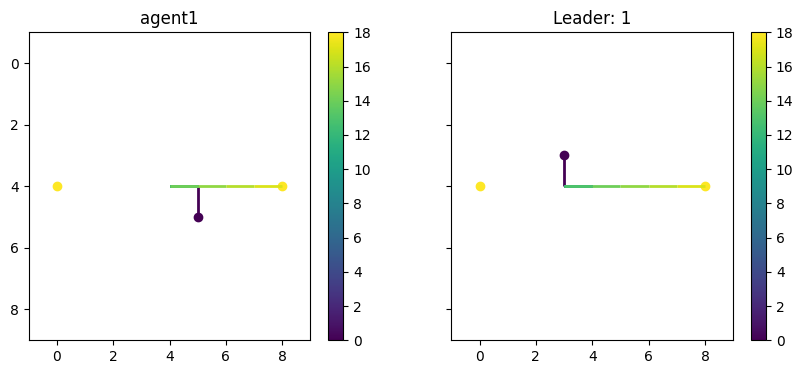

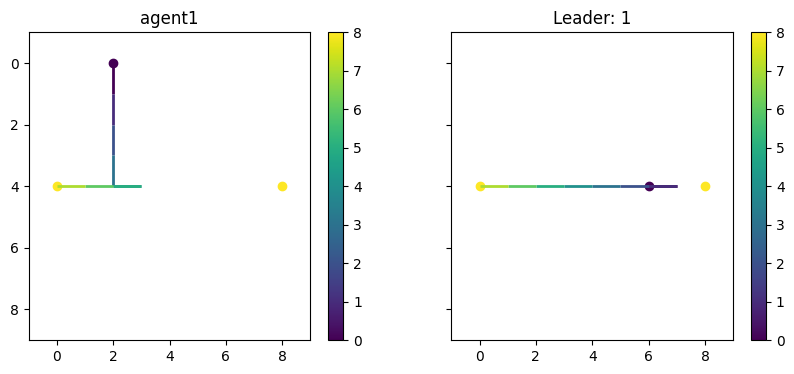

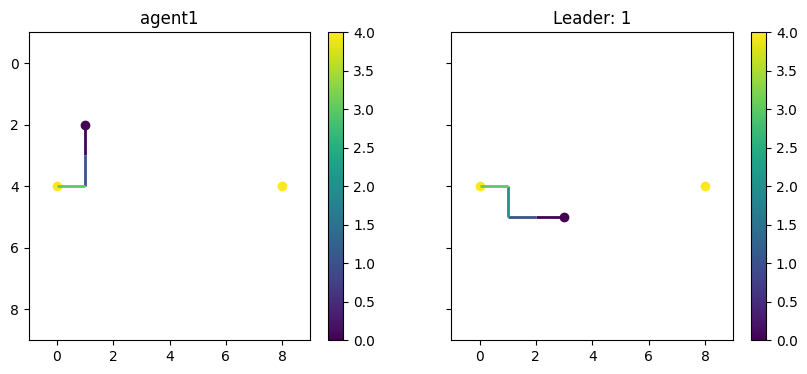

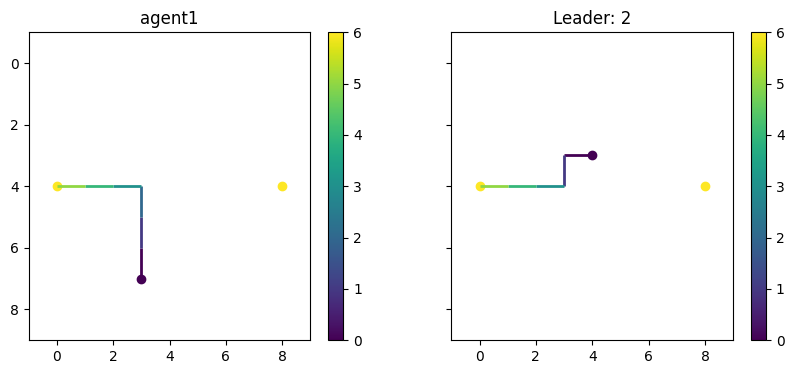

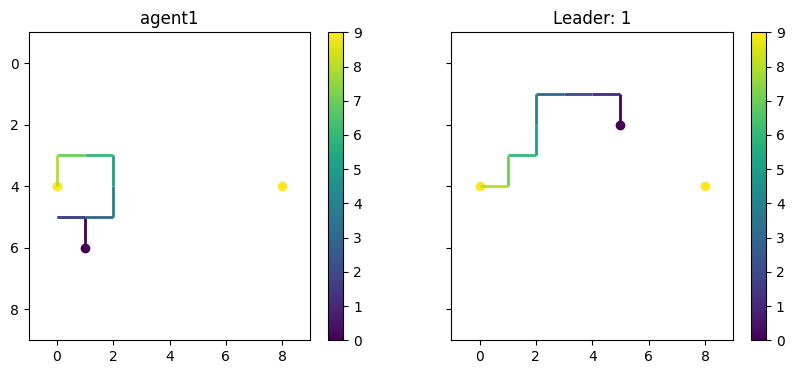

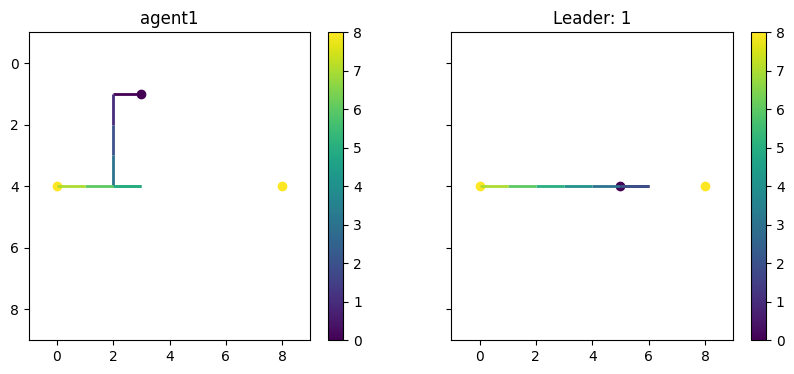

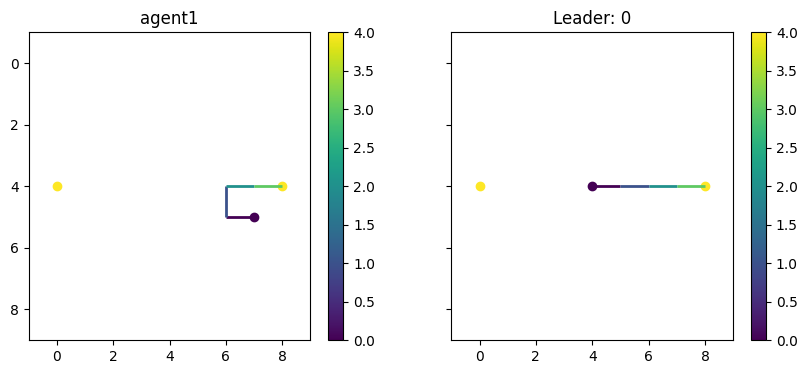

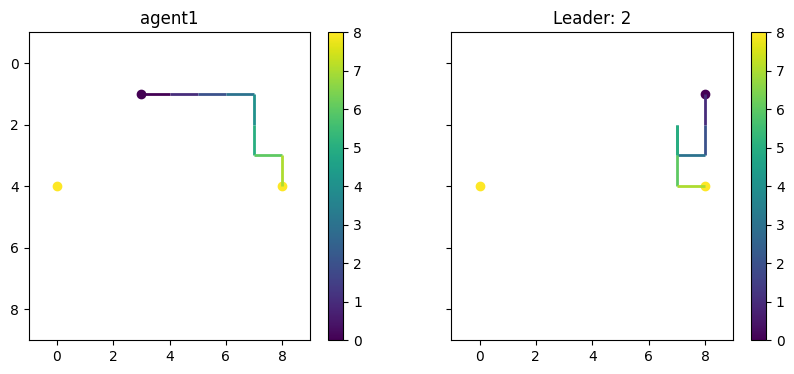

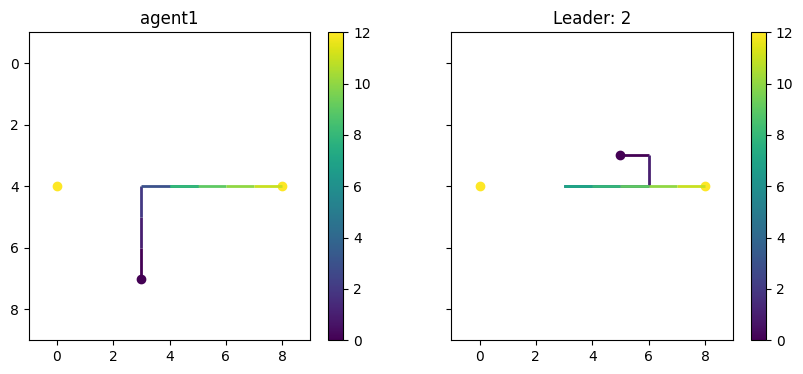

In [11]:
# for i in range(len(data)):
for i in range(10):
    traj1 = [ele[0] for ele in data[i]]
    traj2 = [ele[1] for ele in data[i]]
    if not traj1 == traj2 and len(traj1)<100 and len(traj2)<100:
        fig = plot_trajectory(traj1,traj2, grid_size)
        plt.title('Leader: {}'.format(find_leader(traj1,traj2)))
        fig.show()
        fig.savefig(save_dir+'traj.png')

In [5]:
plt.close('all')

In [14]:
leader = []
steps = []
for i in range(len(data)):
    if len(data[i])==100:
        continue
    traj1 = [ele[0] for ele in data[i]]
    traj2 = [ele[1] for ele in data[i]]
    leader.append(find_leader(traj1,traj2))
    steps.append(len(traj1))


In [17]:
count = 0
for ele in data:
    if len(ele)==100:
        count += 1
print('Failed probability: {:.2f}'.format(count/len(data)))

Failed probability: 0.08


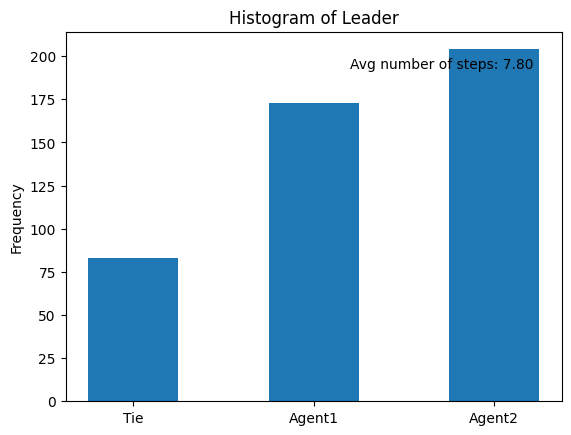

In [18]:
fig = plt.figure()  
plt.hist(leader, bins=[0,1,2,3], align='left', rwidth=0.5)
plt.xticks([0,1,2], ['Tie', 'Agent1', 'Agent2'])
# plt.xlabel('Leader')
plt.ylabel('Frequency')
plt.title('Histogram of Leader')
ymin,ymax = plt.ylim()
plt.text(1.2, ymax*0.9, 'Avg number of steps: {:.2f}'.format(np.mean(steps)))
plt.show()
fig.savefig(model_dir+'leader.png')

### Sensitivity to parameter selection 

In [ ]:
import numpy as np
# collect all together_rewrad parameters
together_reward = np.arange(11)

leader_probability = []
steps = []
Trials = 100
for r in together_reward:
    model_dir = 'experiments/Independent/together_test{}/'.format(r)
    save_dir = model_dir+ 'eval/'
    leader = []
    step = []
    with open(save_dir+'eval.pkl', 'rb') as f:
        data = pickle.load(f)
    for i in range(len(data)):
        traj1 = [ele[0] for ele in data[i]]
        traj2 = [ele[1] for ele in data[i]]
        leader.append(find_leader(traj1,traj2))
        step.append(len(traj1))
    steps.append(step)
    leader_count = Counter(leader)
    leader_probability.append([leader_count[0]/Trials, leader_count[1]/Trials, leader_count[2]/Trials])


In [ ]:
print([np.mean(ele) for ele in steps])
print(leader_probability)

[4.48, 4.35, 4.5, 4.16, 4.46, 4.32, 4.23, 4.29, 4.91, 4.37, 14.77]
[[0.45, 0.27, 0.28], [0.48, 0.29, 0.23], [0.38, 0.3, 0.32], [0.53, 0.18, 0.29], [0.46, 0.29, 0.25], [0.5, 0.25, 0.25], [0.48, 0.21, 0.31], [0.49, 0.3, 0.21], [0.41, 0.32, 0.27], [0.46, 0.27, 0.27], [0.08, 0.66, 0.26]]


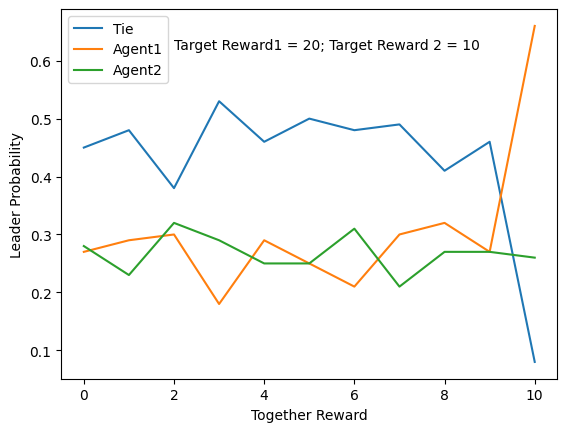

In [ ]:
fig = plt.figure()
plt.plot(together_reward, [ele[0] for ele in leader_probability], label='Tie')
plt.plot(together_reward, [ele[1] for ele in leader_probability], label='Agent1')
plt.plot(together_reward, [ele[2] for ele in leader_probability], label='Agent2')
plt.xlabel('Together Reward')
plt.ylabel('Leader Probability')
# plt.title('Probability of Leader')
ymin,ymax = plt.ylim()
plt.text(2,ymax*0.9,'Target Reward1 = 20; Target Reward 2 = 10')
plt.legend()
plt.show()

In [ ]:
leader_probability

[[0.43, 0.2, 0.37], [1.0, 0.0, 0.0], [0.08, 0.92, 0.0]]

# Test: classfier of Agent 2 action
- input: agent1 state, agent2 state
- output: agent2 action (classifcation problem)
- traces: evaluation trials 

In [ ]:
agent = JointAgent(5,5, draw_radius=20, alpha=0.1, gamma=0.9, epsilon=0.5)
# model_dir = 'experiments/priors/OneDiffusion/'
model_dir = 'experiments/Independent/together_test4/'
with open(model_dir+'eval/eval.pkl', 'rb') as f:
    data = pickle.load(f)

In [ ]:
len(data)

100

In [ ]:
input1 = [ele[0] for ele in data[0]]
input2 = [ele[1] for ele in data[0]]
input = np.concatenate((input1, input2), axis=1)
output = np.ravel([ele[3] for ele in data[0]])

In [ ]:
output.shape

(4,)

In [ ]:


total_mat = np.concatenate((input, output), axis=1)
unique_rows = np.unique(total_mat, axis=0)


TypeError: The axis argument to unique is not supported for dtype object

In [ ]:
from sklearn.linear_model import LogisticRegression

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(input, output, test_size=0.2, random_state=42)

# Create a logistic regression classifier
classifier = LogisticRegression()

# Train the classifier
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Calculate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.75


/home/yuchen/anaconda2/envs/py3.8/lib/python3.10/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
classifier.predict(np.array(agent.get_state(0)+ agent.get_state(1)).reshape(1,-1))[0]


'right'

In [ ]:
y_test

array(['left', 'left', 'left', 'right', 'left', 'left', 'left', 'left',
       'right', 'left', 'left', 'right', 'right', 'right', 'right',
       'right', 'left', 'left', 'left', 'right', 'left', 'left', 'left',
       'left', 'right', 'left', 'left', 'left', 'right', 'right', 'right',
       'left', 'right', 'left', 'right', 'left', 'left', 'right', 'right',
       'left', 'right', 'right', 'right', 'right', 'left', 'right',
       'right', 'left', 'right', 'right', 'left', 'right', 'left', 'left',
       'right', 'left', 'right', 'right', 'left', 'left', 'right', 'left',
       'right', 'right', 'right', 'right', 'left', 'right', 'left',
       'right', 'right', 'left', 'right', 'left', 'right', 'right',
       'left', 'right', 'right', 'right', 'left', 'right', 'right',
       'right', 'left', 'left', 'left', 'left', 'left', 'left', 'left',
       'left', 'left', 'left', 'left', 'left', 'right', 'right', 'right',
       'right', 'left', 'right', 'right', 'right', 'left', 'left', 'l